In [7]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y = np.array([[0],[1],[1],[0]], dtype=np.float32)

# Build MLP
keras_model = keras.Sequential([
    layers.Dense(4, input_dim=2, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
keras_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.05),
              loss='binary_crossentropy', metrics=['accuracy'])
keras_model.fit(X, y, epochs=500, verbose=0)

# Evaluate
predictions = keras_model.predict(X)
print("Keras Predictions:")
for i in range(4):
    print(f"Input: {X[i]} -> Predicted: {predictions[i][0]:.4f} -> Rounded: {round(predictions[i][0])} -> Actual: {y[i][0]}")

loss, acc = keras_model.evaluate(X, y, verbose=0)
print(f"\nFinal Accuracy: {acc*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Keras Predictions:
Input: [0. 0.] -> Predicted: 0.6663 -> Rounded: 1 -> Actual: 0.0
Input: [0. 1.] -> Predicted: 0.6663 -> Rounded: 1 -> Actual: 1.0
Input: [1. 0.] -> Predicted: 0.6663 -> Rounded: 1 -> Actual: 1.0
Input: [1. 1.] -> Predicted: 0.0012 -> Rounded: 0 -> Actual: 0.0

Final Accuracy: 75.00%


In [8]:
import torch
import torch.nn as nn

# Dataset
X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

# Build MLP
class XORNet(nn.Module):
    def __init__(self):
        super(XORNet, self).__init__()
        self.hidden = nn.Linear(2, 4)   # hidden layer
        self.output = nn.Linear(4, 1)   # output layer
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x

torch_model = XORNet()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(torch_model.parameters(), lr=0.05)

# Train
epochs = 500
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = torch_model(X)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()

# Evaluate
with torch.no_grad():
    predictions = torch_model(X)
    print("PyTorch Predictions:")
    for i in range(4):
        pred_val = predictions[i][0].item()
        print(f"Input: {X[i].tolist()} -> Predicted: {pred_val:.4f} -> Rounded: {round(pred_val)} -> Actual: {y[i][0].item()}")

    accuracy = ((predictions.round() == y).sum().item()) / 4
    print(f"\nFinal Accuracy: {accuracy*100:.2f}%")

PyTorch Predictions:
Input: [0.0, 0.0] -> Predicted: 0.3335 -> Rounded: 0 -> Actual: 0.0
Input: [0.0, 1.0] -> Predicted: 0.9994 -> Rounded: 1 -> Actual: 1.0
Input: [1.0, 0.0] -> Predicted: 0.3335 -> Rounded: 0 -> Actual: 1.0
Input: [1.0, 1.0] -> Predicted: 0.3335 -> Rounded: 0 -> Actual: 0.0

Final Accuracy: 75.00%


In [9]:
import tensorflow as tf
import numpy as np

# Dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y = np.array([[0],[1],[1],[0]], dtype=np.float32)

# Initialize weights and biases manually
tf.random.set_seed(42)
W1 = tf.Variable(tf.random.normal([2,4]))
b1 = tf.Variable(tf.zeros([4]))
W2 = tf.Variable(tf.random.normal([4,1]))
b2 = tf.Variable(tf.zeros([1]))

optimizer = tf.optimizers.Adam(learning_rate=0.05)

def forward(x):
    hidden = tf.nn.relu(tf.matmul(x, W1) + b1)
    output = tf.nn.sigmoid(tf.matmul(hidden, W2) + b2)
    return output

def loss_fn(y_true, y_pred):
    return tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))

# Train
epochs = 500
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        y_pred = forward(X)
        loss = loss_fn(y, y_pred)
    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))

# Evaluate
predictions = forward(X).numpy()
print("TensorFlow (Low-Level) Predictions:")
for i in range(4):
    print(f"Input: {X[i]} -> Predicted: {predictions[i][0]:.4f} -> Rounded: {round(predictions[i][0])} -> Actual: {y[i][0]}")

accuracy = np.mean(np.round(predictions) == y)
print(f"\nFinal Accuracy: {accuracy*100:.2f}%")

TensorFlow (Low-Level) Predictions:
Input: [0. 0.] -> Predicted: 0.0017 -> Rounded: 0 -> Actual: 0.0
Input: [0. 1.] -> Predicted: 0.9996 -> Rounded: 1 -> Actual: 1.0
Input: [1. 0.] -> Predicted: 0.9998 -> Rounded: 1 -> Actual: 1.0
Input: [1. 1.] -> Predicted: 0.0017 -> Rounded: 0 -> Actual: 0.0

Final Accuracy: 100.00%


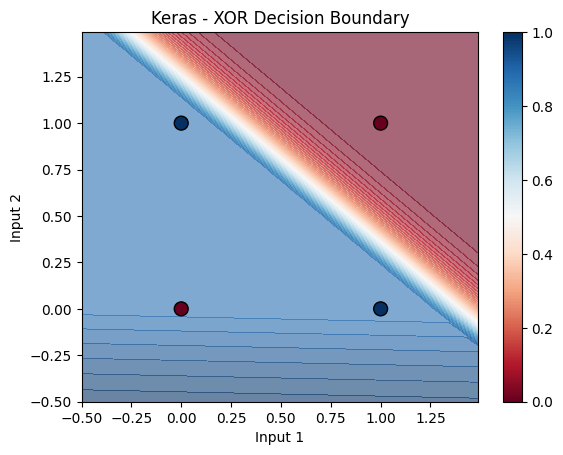

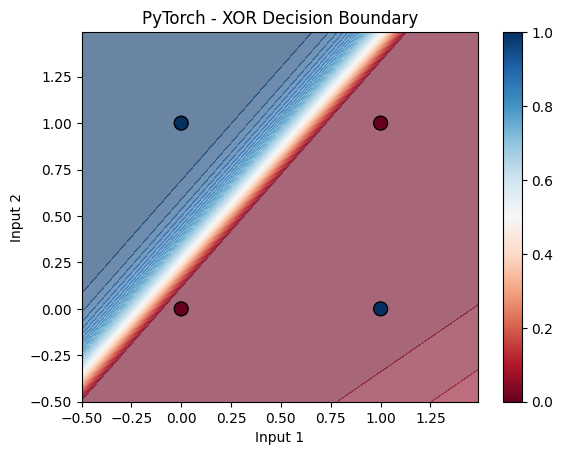

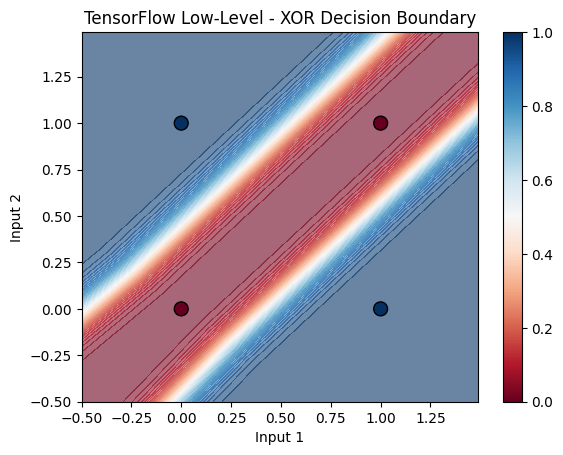

In [10]:
import matplotlib.pyplot as plt

def plot_decision_boundary(predict_fn, X, y, title="Decision Boundary"):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

    Z = predict_fn(grid)
    Z = np.array(Z).reshape(xx.shape)

    plt.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.6)
    plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='RdBu', edgecolors='k', s=100)
    plt.title(title)
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.colorbar()
    plt.show()

plot_decision_boundary(lambda grid: keras_model.predict(grid, verbose=0), X, y, "Keras - XOR Decision Boundary")

plot_decision_boundary(lambda grid: torch_model(torch.tensor(grid)).detach().numpy(), X, y, "PyTorch - XOR Decision Boundary")

plot_decision_boundary(lambda grid: forward(grid).numpy(), X, y, "TensorFlow Low-Level - XOR Decision Boundary")

In [11]:
# Quick comparison: effect of learning rate and epochs (using Keras as example)
configs = [
    {"lr": 0.01, "epochs": 100, "neurons": 4},
    {"lr": 0.05, "epochs": 500, "neurons": 4},
    {"lr": 0.05, "epochs": 500, "neurons": 2},
]

results = []
for cfg in configs:
    m = keras.Sequential([
        layers.Dense(cfg["neurons"], input_dim=2, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=cfg["lr"]),
              loss='binary_crossentropy', metrics=['accuracy'])
    m.fit(X, y, epochs=cfg["epochs"], verbose=0)
    loss, acc = m.evaluate(X, y, verbose=0)
    results.append({**cfg, "final_accuracy": acc})

import pandas as pd
print(pd.DataFrame(results))

     lr  epochs  neurons  final_accuracy
0  0.01     100        4            0.75
1  0.05     500        4            0.75
2  0.05     500        2            0.50
